In [2]:
import duckdb
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from datetime import datetime, timedelta
from collections import defaultdict
# import matplotlib.pyplot as plt
# import seaborn as sns
from ipywidgets import interact, widgets

In [3]:
con = duckdb.connect('../database/ecommerce.duckdb', read_only=True)


In [4]:
df_events = con.execute("SELECT * FROM events").df()

## Funnel Analysis

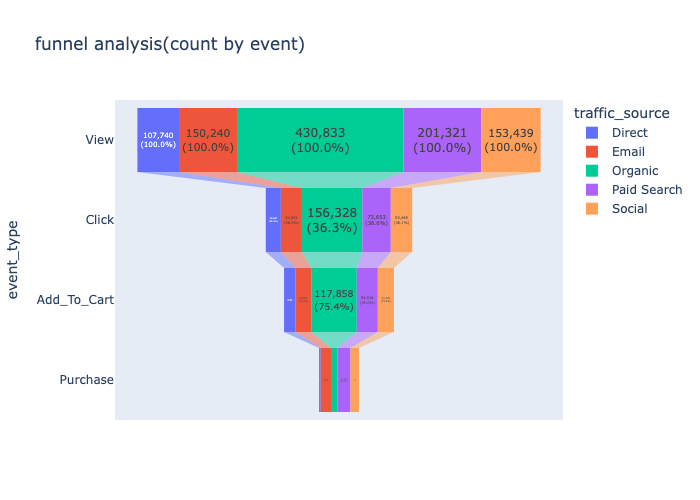

In [5]:
FUNNEL_STAGES = ['View', 'Click', 'Add_To_Cart', 'Purchase']

funnel_data = df_events[df_events['event_type'].isin(FUNNEL_STAGES)].groupby(
    ['traffic_source', 'event_type']
).agg(unique_users=('customer_id', 'count')).reset_index()

funnel_data['event_type'] = pd.Categorical(funnel_data['event_type'], categories=FUNNEL_STAGES, ordered=True)
funnel_data = funnel_data.sort_values(['traffic_source', 'event_type'])


funnel_data['prev_users'] = funnel_data.groupby('traffic_source')['unique_users'].shift(1)
funnel_data['conv_rate'] = (funnel_data['unique_users'] / funnel_data['prev_users'] * 100).fillna(100)

def format_label(row):
    if row['event_type'] == 'view':
        return f"{row['unique_users']:,}"
    else:
        return f"{row['unique_users']:,}<br>({row['conv_rate']:.1f}%)"

funnel_data['display_text'] = funnel_data.apply(format_label, axis=1)

fig = px.funnel(
    funnel_data,
    x='unique_users',
    y='event_type',
    color='traffic_source',
    text='display_text',
    title='funnel analysis(count by event)'
)

fig.update_traces(textposition='inside', textinfo='text')
# fig.show()  # uncomment to see the interactive graph
fig.show('png')

In [9]:
df_events['event_type'].head()

0           View
1    Add_To_Cart
2       Purchase
3    Add_To_Cart
4         Bounce
Name: event_type, dtype: object

## Marketing Attribution using Markov Chain

Total 64035 conversion paths.


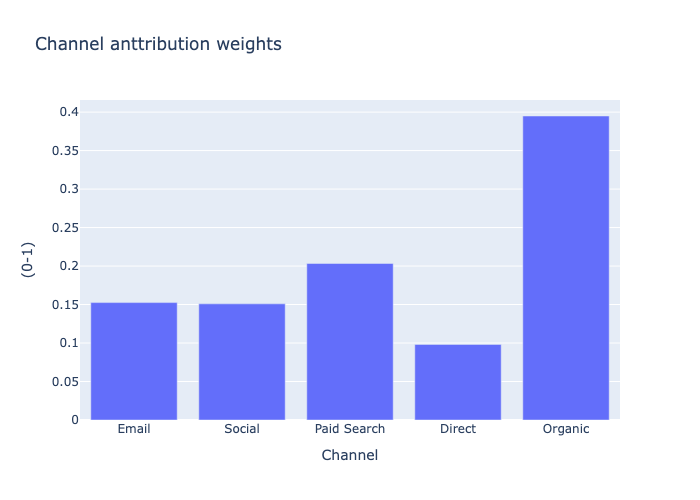


Attribution Weights:
       Channel  Attribution
0        Email     0.152526
1       Social     0.150902
2  Paid Search     0.203404
3       Direct     0.098212
4      Organic     0.394956


In [6]:
CHANNELS = ['Email', 'Social', 'Paid Search', 'Direct', 'Organic']

conver_users = df_events[df_events['event_type'] == 'Purchase']['customer_id'].unique()

paths = []
for user_id in conver_users:

    user_events = df_events[df_events['customer_id'] == user_id].sort_values('timestamp')
    channel = user_events['traffic_source'].iloc[0]
    path = ['Start', channel, 'Conversion']
    paths.append(path)

print(f"Total {len(paths)} conversion paths.")

transitions = defaultdict(lambda: defaultdict(int))
for path in paths:
    for i in range(len(path) - 1):
        transitions[path[i]][path[i+1]] += 1

prob_matrix = defaultdict(dict)
for state, next_states in transitions.items():
    total = sum(next_states.values())
    for next_state, count in next_states.items():
        prob_matrix[state][next_state] = count / total


base_conversion_prob = 1.0

removal_effects = {}
channels_to_test = CHANNELS

for channel in channels_to_test:

    if channel in prob_matrix:

        paths_containing_channel = [p for p in paths if channel in p]
        removal_effects[channel] = len(paths_containing_channel) / len(paths)
    else:
        removal_effects[channel] = 0.0

total_effect = sum(removal_effects.values())
markov_attribution = {k: v / total_effect for k, v in removal_effects.items()}

df_attrib = pd.DataFrame(list(markov_attribution.items()), columns=['Channel', 'Attribution'])
fig_attrib = px.bar(
    df_attrib, x='Channel', y='Attribution', 
    title='Channel anttribution weights',
    labels={'Attribution': '(0-1)'}
)
# fig_attrib.show() # uncomment to see the interactive ver graph
fig_attrib.show('png')
print("\nAttribution Weights:")
print(df_attrib)

## Abandoned Car Rate

In [5]:
# abandoned car rate
category_acr = con.execute("""
    SELECT 
        product_category,
        COUNT(CASE WHEN event_type = 'Add_To_Cart' THEN 1 END) as carts,
        COUNT(CASE WHEN event_type = 'Purchase' THEN 1 END) as purchases
    FROM v_marketing_funnel
    GROUP BY 1
    HAVING carts > 50  
""").df()

category_acr['acr'] = 1 - (category_acr['purchases'] / category_acr['carts'])
category_acr = category_acr.sort_values('acr', ascending=False)

In [6]:
category_acr.head()

,product_category,carts,purchases,acr
3,Beauty,28720,9224,0.678830
4,Fashion,59541,19339,0.675199
0,Grocery,44284,14431,0.674126
5,Sports,31147,10168,0.673548
2,Home,56302,18421,0.672818


In [12]:
con.close()